X Shape: (100, 2)
y Shape: (100,)
LDA Accuracy: 1.00
Coefficients: [[-594.25904805  666.45172111]]
Intercept: [1192.89034587]


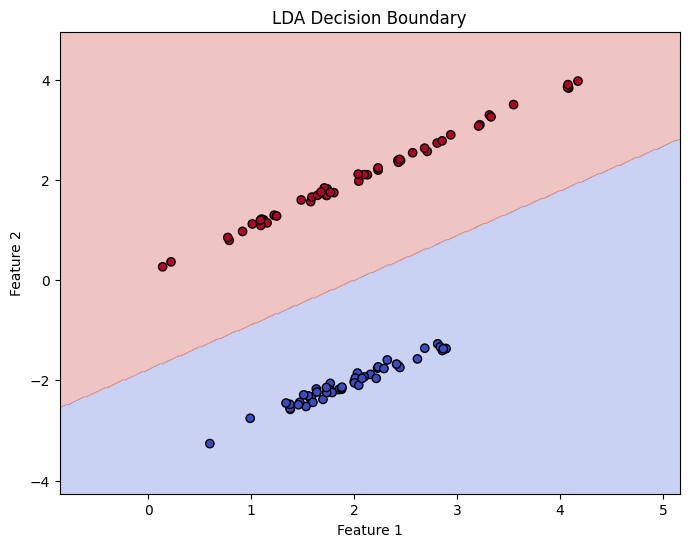

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import numpy as np

def lda_demo():
    """
    LDA demo for binary classification.
    """
    # 1. Generate Binary Data
    X, y = make_classification(n_features=2, n_redundant=0,
                               n_informative=2, n_clusters_per_class=1,
                               class_sep=2.0, random_state=42)

    print(f"X Shape: {X.shape}")
    print(f"y Shape: {y.shape}")

    # 2. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # 3. Apply LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train, y_train)

    # 4. Predict & Score
    acc = lda.score(X_test, y_test)
    print(f"LDA Accuracy: {acc:.2f}")

    # 5. Plot Decision Boundary
    # LDA draws a line that separates the two classes.
    print("Coefficients:", lda.coef_)
    print("Intercept:", lda.intercept_)

    # Create meshgrid for visualization
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict for each point in meshgrid
    Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm)
    plt.title('LDA Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

lda_demo()